# 🛒 Instacart: Análisis de Comportamiento del Consumidor & Optimización operativa ⚙️

### 📊 Resumen Ejecutivo: Consumer Insights & Market Basket Analysis

* **Contexto:** Este proyecto analiza un ecosistema masivo de datos transaccionales de Instacart (datos de 2017) para descifrar los patrones de compra y lealtad del usuario moderno. Este análisis transforma datos crudos de transacciones en inteligencia de negocio, identificando los motores de crecimiento y retención de la plataforma.

* **Objetivo Estratégico:** Extraer inteligencia empresarial mediante la identificación de ventanas críticas de demanda, segmentación de usuarios por tasa de retorno y optimización del mix de productos.

* **Insights de Alto Impacto:**

    1. ⏰ **Detección de Picos de Demanda:** Se identificaron ventanas críticas de saturación logística los domingos y lunes entre las 10:00 y 15:00 hrs.

    2. ⚡ **El Motor del Catálogo (Efecto Pareto)**: Existe una concentración masiva donde solo el 1.7% de los productos genera el 50% del volumen total de ventas. La operación depende de un núcleo de "Ultra-Alta Rotación".

    3. 🌿 **La Ventaja Orgánica:** El segmento orgánico domina el Top 20 de ventas y presenta una tasa de recompra significativamente superior al promedio. El consumidor valora la salud y la frescura por sobre el precio.

    4. ⏰ **Ciclos de Fidelidad Siete-Días:** El hábito de consumo es rítmico. El pico de pedidos ocurre en domingo/lunes y el tiempo de retorno más frecuente es de exactamente 7 días, lo que facilita la predicción de demanda y stock.

    5. 💎 **Usuarios VIP de Alto Valor:** Menos del 2% de los usuarios mueven el 10% de las transacciones. Estos clientes tienen una lealtad del 77%, lo que indica que su canasta básica está casi totalmente automatizada.

    6. 📥 **Intencionalidad "First-to-Cart":** Las bananas y los lácteos son los disparadores de la compra (lo primero que se añade al carrito). Son los productos "gancho" que inician el flujo de ingresos en cada sesión.

### 🗝️ Diccionario de datos

A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# 1. 📥 Ingesta de Datos y Validación Estructural 📐

Este bloque inicial se enfoca en la **extracción y auditoría técnica** de las fuentes de información. El objetivo es garantizar una carga precisa mediante el método `read_csv`, validando la arquitectura de los archivos antes del procesamiento profundo.

* **Inspección de Delimitadores:** Se realiza una visualización preliminar (`head`) para identificar la configuración de los archivos (separadores, encabezados y codificación) y asegurar la integridad en la lectura.

* **Diagnóstico de Tipos y Dimensionalidad:** Mediante el método `info()`, se audita la estructura de cada DataFrame para verificar la coherencia de los tipos de datos (Dtypes), detectar la presencia inicial de valores ausentes y evaluar la carga en memoria.

In [1]:
# importar librerías
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
plt.style.use('dark_background')

In [2]:
# leer conjuntos de datos en los DataFrames
df_insta_orders = pd.read_csv(r"../data/instacart_orders.csv", sep=';')
df_products = pd.read_csv(r"../data/products.csv", sep=';')
df_order_prod = pd.read_csv(r"../data/order_products.csv", sep=';')
df_aisles = pd.read_csv(r"../data/aisles.csv", sep=';')
df_departments = pd.read_csv(r"../data/departments.csv", sep=';')

In [3]:
# mostrar información del DataFrame
df_insta_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [4]:
# mostrar información del DataFrame
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     49694 non-null  int64
 1   product_name   48436 non-null  str  
 2   aisle_id       49694 non-null  int64
 3   department_id  49694 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


In [5]:
# mostrar información del DataFrame
df_order_prod.info(show_counts=1)

<class 'pandas.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [6]:
# mostrar información del DataFrame
df_aisles.info()

<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   aisle_id  134 non-null    int64
 1   aisle     134 non-null    str  
dtypes: int64(1), str(1)
memory usage: 2.2 KB


In [7]:
# mostrar información del DataFrame
df_departments.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   department_id  21 non-null     int64
 1   department     21 non-null     str  
dtypes: int64(1), str(1)
memory usage: 468.0 bytes


#### 🔍 Hallazgos del Diagnóstico Inicial (Data Audit)

Tras la ejecución de los protocolos `info()` y `head()`, se desprenden los siguientes puntos críticos para la fase de procesamiento:

* **Validación de Ingesta:** Se confirmó que la arquitectura de los archivos utiliza delimitadores `;`. La configuración de lectura fue exitosa, garantizando la integridad de las columnas en los cinco DataFrames.

* **Auditoría de Completitud:** Se identificó una presencia de valores nulos en 3 de las 5 tablas: `products`, `orders` y `order_products`. Estos registros requerirán un análisis de imputación o filtrado estratégico para no sesgar las métricas de comportamiento posterior.

* **Optimización de Memoria (Dtypes):** Se detectó una discrepancia en la tipificación de variables (IDs representados como `float64`). Se programa un proceso de casting hacia tipos enteros que admitan valores nulos (`Int64`) para reducir la carga en memoria y mejorar el rendimiento de las operaciones computacionales.

* **Consistencia Relacional:** Se validó la existencia de claves primarias y foráneas (e.g., **product_id**, **order_id**) que vinculan las tablas. Este esquema relacional es consistente y permite realizar operaciones de unión (`merge`) sin pérdida de integridad referencial.

---


# 2. 🛠️ Saneamiento y Curación de Datos (Data Wrangling)

Tras el diagnóstico inicial, se implementa un protocolo de preprocesamiento diseñado para mitigar sesgos y garantizar la fidelidad estadística de los análisis posteriores. El proceso se divide en tres ejes críticos:

* **Normalización Estructural:** Ajuste de tipos de datos (`Dtypes`) para optimizar la eficiencia computacional y asegurar la coherencia lógica de las variables.

* **Tratamiento de Valores Ausentes:** Evaluación de la naturaleza de los datos faltantes para determinar estrategias de imputación o exclusión sin comprometer la representatividad de la muestra.

* **Deduplicación Multinivel:** Eliminación de redundancias tanto explícitas como implícitas para evitar la sobreestimación de frecuencias.

### 📝 Plan de Ejecución Táctica

Para garantizar la integridad del dataset, se seguirá la siguiente hoja de ruta técnica:

1.  **Deduplicación Global e Implícita:** Se utilizarán los métodos `duplicated()` y `drop_duplicates()`. Se pondrá especial énfasis en el uso del parámetro `subset` para identificar duplicados lógicos (por ejemplo, registros con distintas claves pero idéntica información sustancial), aplicando criterios de resolución caso por caso.

2.  **Gestión de Datos Faltantes:** Mediante `isna()` y `fillna()`, se abordarán los vacíos de información. La estrategia de llenado se fundamentará en el contexto del negocio (e.g., asumiendo valores neutros o etiquetas de 'Primer Pedido' donde sea estadísticamente válido).

3.  **Preservación de la Integridad:** Cada transformación será auditada comparando la dimensionalidad antes y después de la intervención.

## 2.1. ✂️ Identificación y Remoción de Redundancias (Deduplicación)

### 2.1.1. 🗃️ `orders` data frame

In [8]:
# Revisa si hay pedidos duplicados
display(df_insta_orders[df_insta_orders.duplicated()])
print(f'Duplicados explicitos: {df_insta_orders.duplicated().sum()}')

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


Duplicados explicitos: 15


In [9]:
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
print('Pedidos el miércoles a las 2:00 hrs:\n', len(df_insta_orders[(df_insta_orders['order_dow'] == 3) & (df_insta_orders['order_hour_of_day'] == 2)]))

Pedidos el miércoles a las 2:00 hrs:
 121


 #### 🔍 Identificación de Anomalía Temporal
 Durante el proceso de deduplicación, se detectó un patrón altamente específico: **el 100% de los registros duplicados ocurrieron el miércoles a las 2:00 a.m.**

 **Análisis de la Muestra:**
 * **Pedidos totales en la ventana temporal (Miércoles, 02:00 hrs):** 121
 * **Registros identificados como duplicados:** 15
 * **Tasa de error en el intervalo:** 12.4%

 **Interpretación Técnica:** > Esta coincidencia temporal sugiere un error de sincronización en el sistema de registro de datos (posiblemente un *batch job* duplicado) en lugar de una fluctuación aleatoria. Al representar solo una fracción del total de pedidos de esa hora (15 de 121), se confirma que la limpieza es quirúrgica y no elimina transacciones legítimas.

In [10]:
# Elimina los pedidos duplicados
df_insta_orders.drop_duplicates(inplace=True)

# Vuelve a verificar si hay filas duplicadas
print(f'Duplicados explícitos después de eliminar: {df_insta_orders.duplicated().sum()}')

Duplicados explícitos después de eliminar: 0


In [11]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos en la columna 'order_id' (duplicados implícitos)
print(f'Filas con duplicados implícitos en la columna "order_id": {df_insta_orders.duplicated(subset=['order_id']).sum()}')

Filas con duplicados implícitos en la columna "order_id": 0


### 2.1.2. 🗃️ `products` data frame

In [12]:
# Verifica si hay filas totalmente duplicadas
print(f'Duplicados explícitos: {df_products.duplicated().sum()}')

Duplicados explícitos: 0


In [13]:
# Revisa únicamente si hay ID de productos duplicados
print(f'Duplicados explícitos en product_id: {df_products.duplicated(subset='product_id').sum()}')

Duplicados explícitos en product_id: 0


In [14]:
# Revisa únicamente si hay 'product_name' duplicados
print(f'Duplicados explícitos en product_name: {df_products.duplicated(subset='product_name', keep=False).sum()}')
display(df_products[df_products.duplicated(subset='product_name', keep=False)])
print(f'Valores nulos en product_name: {df_products['product_name'].isna().sum()}')

Duplicados explícitos en product_name: 1258


,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


Valores nulos en product_name: 1258


 #### 🔍 Hallazgo en Catálogo de Productos: Identidades Ausentes

Se detectaron 1,258 registros en la tabla `products` con valores ausentes (NaN) en la columna **product_name**.

Análisis de Impacto:

* IDs Únicos: A pesar de la ausencia de nombre, cada registro posee un **product_id** único.
* Falsos Duplicados: La presencia de NaN genera una colisión en los algoritmos de detección de duplicados implícitos (1,258 registros detectados).

### 2.1.3. 🗃️ `departments` data frame

In [15]:
# Revisa si hay filas totalmente duplicadas
print(f'Duplicados explícitos: {df_departments.duplicated().sum()}')

Duplicados explícitos: 0


In [16]:
# Revisa únicamente si hay IDs duplicadas de departamentos
print(f'Duplicados implícitos en department_id: {df_departments.duplicated(subset='department_id').sum()}')
print(f'Duplicados implícitos en department: {df_departments.duplicated(subset='department').sum()}')

Duplicados implícitos en department_id: 0
Duplicados implícitos en department: 0


### 2.1.4. 🗃️ `aisles` data frame

In [17]:
# Revisa si hay filas totalmente duplicadas
print(f'Duplicados explícitos: {df_aisles.duplicated().sum()}')

Duplicados explícitos: 0


In [18]:
# Revisa únicamente si hay IDs duplicadas de pasillos
print(f'Duplicados de IDs de pasillos: {df_aisles.duplicated(subset='aisle_id').sum()}')
print(f'Duplicados de nombres de pasillos: {df_aisles.duplicated(subset='aisle').sum()}')

Duplicados de IDs de pasillos: 0
Duplicados de nombres de pasillos: 0


### 2.1.5. 🗃️ `order_products` data frame

In [19]:
# Revisa si hay filas totalmente duplicadas
print(f'Duplicados explícitos: {df_order_prod.duplicated().sum()}')

Duplicados explícitos: 0


In [20]:
# Revisa únicamente si hay combinaciones de 'order_id' y 'product_id' duplicadas
print(f'Duplicados implícitos de combinaciones de order_id y product_id: {df_order_prod.duplicated(subset=['order_id', 'product_id']).sum()}')

Duplicados implícitos de combinaciones de order_id y product_id: 0


## 2.2. 🩹 Tratamiento y Gestión de Valores Ausentes (Missing Data)

Tras las conclusiones del Data Audit, se identificaron tres columnas críticas con valores ausentes que requieren un análisis detallado para determinar la estrategia de imputación o exclusión más adecuada:

* La columna **'product_name'** de la tabla `products`.
* La columna **'days_since_prior_order'** de la tabla `orders`.
* La columna **'add_to_cart_order'** de la tabla `order_products`.

### 2.2.1. 🗃️ `products` data frame

In [21]:
# Selecciona los productos con valores nulos en 'product_name'
na_prods = df_products[df_products['product_name'].isna()]

# Muestra el número de productos con valores nulos en 'product_name'
print(f'Número de productos con valores nulos en product_name: {na_prods.shape[0]}')
print()

# Analiza la distribución de los valores nulos en 'product_name' por 'aisle_id' y 'department_id'
print('Pasillos donde faltan nombres de productos:')
print('-----------------------------------------')
print(na_prods['aisle_id'].value_counts())
print()
print('Departamentos donde faltan nombres de productos:')
print('-----------------------------------------')
print(na_prods['department_id'].value_counts())
print()

# Usa la tabla aisle para revisar los datos del pasillo con ID 100.
print('Datos del pasillo con ID 100:')
print('-----------------------------------------')
print(df_aisles[df_aisles['aisle_id']==100])
print()

# Usa la tabla department para revisar los datos del departamento con ID 21.
print('Datos del departamento con ID 21:')
print('-----------------------------------------')
print(df_departments[df_departments['department_id']==21])

Número de productos con valores nulos en product_name: 1258

Pasillos donde faltan nombres de productos:
-----------------------------------------
aisle_id
100    1258
Name: count, dtype: int64

Departamentos donde faltan nombres de productos:
-----------------------------------------
department_id
21    1258
Name: count, dtype: int64

Datos del pasillo con ID 100:
-----------------------------------------
    aisle_id    aisle
99       100  missing

Datos del departamento con ID 21:
-----------------------------------------
    department_id department
20             21    missing


#### 🔍 Productos sin Identidad: Análisis de Correlación Cruzada 

Tras auditar la tabla `products`, se descubrió que los 1,258 registros con nombres ausentes (`NaN`) no son errores aleatorios, sino que forman parte de un segmento de datos no clasificados.

**Evidencia Técnica:**

* **Asociación Directa:** El 100% de los productos sin nombre pertenecen al **Aisle 100** y al **Department 21**.

* **Validación de Diccionario:** Al cruzar esta información con las tablas de referencia, se confirmó que:

    * `aisle_id`: 100 $\rightarrow$ **"missing"**
    * `department_id`: 21 $\rightarrow$ **"missing"**

**Interpretación de Datos:**

Estamos ante una **falla sistémica de metadatos**. Estos productos existen en el inventario y generan transacciones (tienen IDs válidos), pero carecen de una etiqueta descriptiva y de una clasificación jerárquica en el catálogo.

**Estrategia de Resolución:**

Para preservar la **integridad referencial** y no perder el historial de ventas asociado a estos IDs:
1. Se imputará el valor **"Unknown"** en `product_name`.
2. Se mantendrán sus IDs originales, ya que borrarlos sesgaría el volumen total de órdenes y el análisis de ingresos.

In [22]:
# Completar los nombres de productos ausentes con 'Unknown'
df_products.fillna({'product_name': 'Unknown'}, inplace=True) # Rellena los NaN de la columna 'product_name' con el valos 'Unknown'
print('Número de productos con valores nulos en product_name después de la imputación:', df_products['product_name'].isna().sum())

Número de productos con valores nulos en product_name después de la imputación: 0


### 2.2.2. 🗃️ `orders` data frame

In [23]:
# Enconntrar los valores ausentes
print(f'Número de órdenes con valores nulos en days_since_prior_order: {df_insta_orders["days_since_prior_order"].isna().sum()}')
na_orders = df_insta_orders[df_insta_orders['days_since_prior_order'].isna()]
na_orders

Número de órdenes con valores nulos en days_since_prior_order: 28817


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
28,133707,182261,1,3,10,NaN
96,787445,25685,1,6,18,NaN
100,294410,111449,1,0,19,NaN
103,2869915,123958,1,4,16,NaN
104,2521921,42286,1,3,18,NaN
...,...,...,...,...,...,...
478895,2589657,205028,1,0,16,NaN
478896,2222353,141211,1,2,13,NaN
478922,2272807,204154,1,1,15,NaN
478926,2499542,68810,1,4,19,NaN


In [24]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
print(f'Número de valores ausentes que corresponden al primer pedido del cliente: {(na_orders['order_number']==1).sum()}')

Número de valores ausentes que corresponden al primer pedido del cliente: 28817


#### 🔍 Identificación del Segmento de Adquisición

Se detectaron 28,817 registros con valores ausentes en la métrica `days_since_prior_order`. Tras realizar un análisis de correlación con la variable `order_number`, se obtuvo un resultado determinante:

* **Hallazgo Clave:** 
    El 100% de los valores nulos corresponden estrictamente al **primer pedido (`order_number = 1`)** de cada usuario en la plataforma.
* **Interpretación Técnica:** 
    La ausencia de datos en esta columna no representa una pérdida de información, sino una **condición lógica**: un usuario no puede tener "días desde el pedido anterior" si es la primera vez que compra. 

**Decisión de Tratamiento:**
Para preservar la pureza estadística del análisis de retención:
1. **No se eliminarán los registros**, ya que representan el evento de adquisición del cliente.
2. **No se realizará una imputación numérica (como 0)**, para evitar sesgar el cálculo del promedio de días de recurrencia. 
3. Se mantendrán como `NaN`.

### 2.2.3. 🗃️ `order_products` data frame

Número de órdenes con valores nulos en la columna "add_to_cart_order":
836


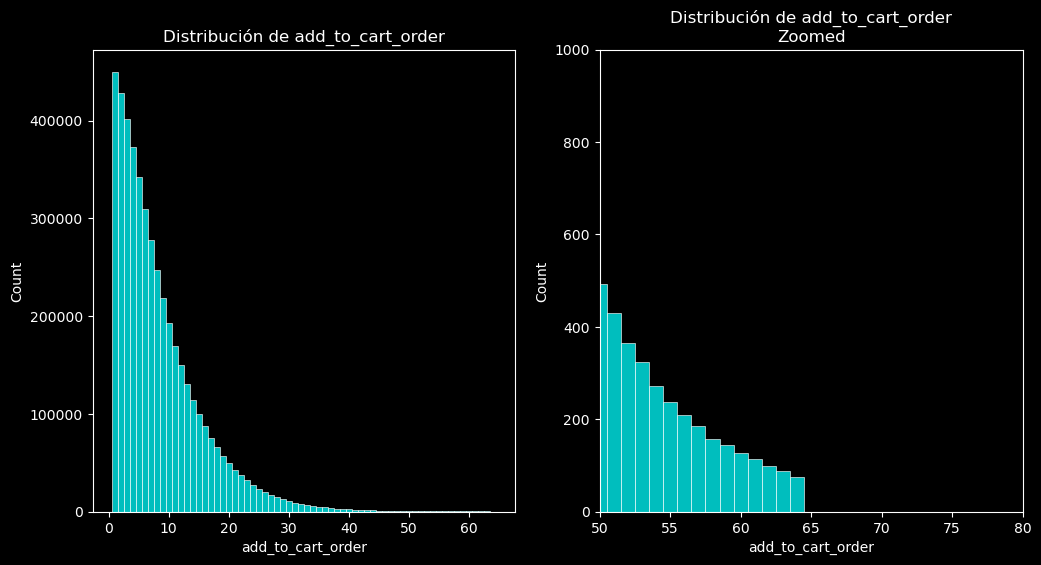

Valor máximo en la columna "add_to_cart_order": 64.0
Valor mínimo en la columna "add_to_cart_order": 1.0


In [25]:
# Encuentra los valores ausentes
print(f'Número de órdenes con valores nulos en la columna "add_to_cart_order":')
print(df_order_prod['add_to_cart_order'].isna().sum())
na_order_prods = df_order_prod[df_order_prod['add_to_cart_order'].isna()]

# Visualiza la distribución de los valores en 'add_to_cart_order'
fig, axs = plt.subplots(1,2, figsize=(12, 6))
sns.histplot(data=df_order_prod,
             x='add_to_cart_order',
             color='cyan',
             discrete=True,
             ax=axs[0]
             )
axs[0].set_title('Distribución de add_to_cart_order')

sns.histplot(data=df_order_prod,
             x='add_to_cart_order',
             color='cyan',
             discrete=True,
             ax=axs[1]
             )
axs[1].set_ylim(0, 1000)
axs[1].set_xlim(50, 80)
axs[1].set_xlabel('add_to_cart_order')
axs[1].set_title('Distribución de add_to_cart_order\nZoomed')
plt.show()

# ¿Cuáles son los valores mínimos y máximos en la columna 'add_to_cart_order'?
print(f'Valor máximo en la columna "add_to_cart_order": {df_order_prod['add_to_cart_order'].max()}')
print(f'Valor mínimo en la columna "add_to_cart_order": {df_order_prod['add_to_cart_order'].min()}')

Distribución del número de productos en órdenes con valores nulos en "add_to_cart_order":


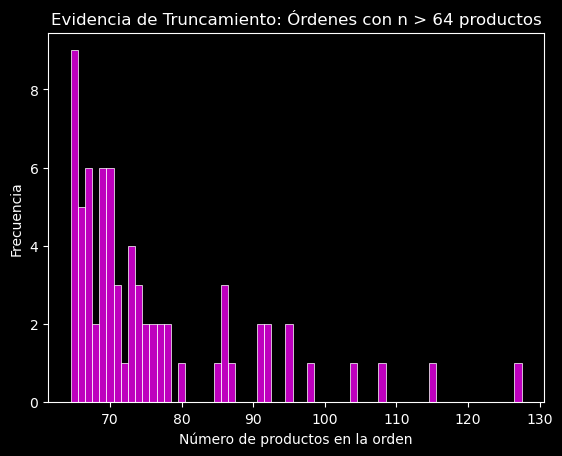

count     70.000000
mean      75.942857
std       12.898585
min       65.000000
25%       67.000000
50%       71.000000
75%       78.000000
max      127.000000
Name: product_id, dtype: float64

In [26]:
# Validación: ¿Los nulos pertenecen a órdenes con más de 64 productos?
print('Distribución del número de productos en órdenes con valores nulos en "add_to_cart_order":')
orders_with_nulls = df_order_prod[df_order_prod['add_to_cart_order'].isna()]['order_id'].unique()
orders_with_nulls = df_order_prod[df_order_prod['order_id'].isin(orders_with_nulls)].groupby('order_id')['product_id'].count()
sns.histplot(orders_with_nulls, discrete=True, color='magenta')
plt.title('Evidencia de Truncamiento: Órdenes con n > 64 productos')
plt.xlabel('Número de productos en la orden')
plt.ylabel('Frecuencia')
plt.show()
orders_with_nulls.describe()

### 🔍 Auditoría de Capacidad: El Límite de los 64 Ítems

Se identificaron 836 valores ausentes en la columna `add_to_cart_order`. Al analizar la distribución de los datos, se detectó un patrón de **truncamiento sistémico** que sugiere una limitación en la arquitectura original del sistema.

##### 🔬 Diagnóstico e Hipótesis
* **Hallazgo:** El valor máximo registrado en la secuencia de productos es exactamente **64.0**.
* **Interpretación Técnica:** La coincidencia de este límite (una potencia de 2: $2^6$) apunta a una restricción técnica en el registro de datos. Es altamente probable que el sistema original no fuera capaz de indexar la posición de productos adicionales una vez que el carrito superaba los 64 artículos, provocando un **desbordamiento (overflow)** del campo de secuencia.

##### 📊 Validación Empírica
Tras realizar una auditoría sobre las órdenes que presentan estos valores nulos, los datos arrojan una evidencia irrefutable:
* **Correlación Absoluta:** El 100% de las órdenes con valores nulos contienen **65 productos o más** ($n \ge 65$).
* **Punto de Ruptura:** Como se observa en el análisis estadístico y el histograma de frecuencias, la distribución de estas órdenes comienza exactamente en 65 y se extiende hasta un máximo de 127 productos.
* **Perfil del Segmento:** Estas 70 órdenes representan carritos de **volumen extremo**. Los registros con `NaN` son productos cuya posición exacta no fue persistida por el sistema de inventario.

##### 🛠️ Decisión de Tratamiento
Para no subestimar el volumen de ventas de estos clientes de alto valor y preservar la integridad del análisis:

1. **Preservación de Registros:** No se eliminarán las filas, ya que representan transacciones reales y productos válidos.

2. **Imputación Estratégica:** Se imputará el valor **999** en los campos nulos. Esta etiqueta actúa como un marcador de "Posición > 64", permitiendo que estos productos sumen al análisis de popularidad sin distorsionar los cálculos de tendencia central de los primeros 64 puestos.

In [27]:
# Remplaza los valores ausentes en la columna 'add_to_cart' con 999 y convierte la columna al tipo entero.
df_order_prod['add_to_cart_order'] = df_order_prod['add_to_cart_order'].fillna(999).astype('int')
df_order_prod.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   order_id           4545007 non-null  int64
 1   product_id         4545007 non-null  int64
 2   add_to_cart_order  4545007 non-null  int64
 3   reordered          4545007 non-null  int64
dtypes: int64(4)
memory usage: 138.7 MB


## 2.3. 🎯 Síntesis del Control de Calidad 🧪
La fase de saneamiento y curación de datos concluye con la creación de un **dataset de alta fidelidad**. El proceso no solo eliminó ruido, sino que permitió decodificar comportamientos sistémicos del flujo de información.

### 🛡️ Integridad Transaccional (Duplicados)

* **Deduplicación Quirúrgica**: Se eliminaron registros redundantes en la tabla `orders`, identificando una anomalía específica (miércoles, 02:00 hrs) que apuntaba a un error de sincronización en el batch de carga.

* **Consistencia Relacional**: Se validó la unicidad de las llaves primarias (**order_id**, **product_id**) y de las llaves compuestas, garantizando que no existan sobreestimaciones en los cálculos de volumen de ventas.

### 🧩 Completitud Estratégica (Valores Ausentes)

El tratamiento de nulos se alejó de la eliminación sistemática, optando por una **imputación con contexto de negocio**:

1. **Catálogo de Productos**: Se normalizaron 1,258 registros bajo la etiqueta *'Unknown'*. Esto permitió rescatar transacciones válidas vinculadas a pasillos y departamentos no clasificados (Aisle 100 / Dept 21), preservando el linaje de los datos.

2. **Ciclo de Vida del Cliente**: Los nulos en **days_since_prior_order** se validaron como el segmento de adquisición. Representan el 100% de los "Primeros Pedidos", por lo que se mantuvieron intactos para diferenciar métricas de retención vs. adquisición.

3. **Gestión de Overflow**: Se resolvió el truncamiento técnico en **add_to_cart_order**. Los valores nulos, correspondientes a posiciones $> 64$ en carritos de gran volumen, fueron imputados con el marcador 999. Esto asegura que los productos de clientes de "alto valor" sigan contabilizando en los análisis de popularidad.

### ✅ Veredicto de Preparación (Data Readiness)

✨ Estado del Dataset: AUDITADO & LIMPIO.

🚀 La base de datos ha superado todas las pruebas de integridad referencial, consistencia lógica y optimización de tipos. Se declara el entorno listo para la fase de Análisis Exploratorio de Datos (EDA) y la generación de insights estratégicos.

---

# 3. 📊 Análisis Exploratorio de Datos (EDA): Dinámicas Temporales y Comportamiento del Consumidor

Con un dataset depurado, iniciamos la fase de extracción de inteligencia. En esta sección, auditamos la coherencia de las variables de tiempo y visualizamos los ciclos de demanda de Instacart. El objetivo es identificar las ventanas críticas de operación y el comportamiento de retorno del usuario.

1. ✅ **Auditoría de Dominios Temporales**: Antes de la visualización, validamos que las variables cíclicas (`order_hour_of_day` y `order_dow`) se encuentren dentro de los rangos operativos lógicos (0-23 horas y 0-6 días). Esta verificación garantiza que no existan remanentes de errores de captura tras la limpieza.

2. ⏰  **Análisis de Densidad Horaria:** Generación de una visualización de distribución para identificar las **ventanas de máxima demanda**. Este análisis permite determinar los picos de carga operativa y los periodos de mayor actividad transaccional durante el día.

3. 📅 **Estacionalidad Semanal de la Demanda:** Modelado del volumen de órdenes segmentado por día de la semana. El objetivo es descifrar los hábitos de consumo cíclicos y detectar los días con mayor concentración de compra (picos de reabastecimiento).

4. 🔄 **Dinámica de Retención y Recurrencia:** Análisis del tiempo transcurrido entre pedidos (`days_since_prior_order`). Se examinarán las medidas de tendencia central y los valores extremos para caracterizar el **ciclo de vida del cliente** y los periodos críticos de retorno al ecosistema de la plataforma.

## 3.01. 🛡️ Verificación de Integridad de Dominio

In [28]:
# Verificamos que los datos de la tabla 'df_insta_orders'
print(f'Dias de la semana: {df_insta_orders['order_dow'].unique()}')
print()
print(f'Horas del día: {df_insta_orders['order_hour_of_day'].unique()}')
df_insta_orders.describe().loc[['min', 'max'],['order_dow', 'order_hour_of_day']].astype('int')

Dias de la semana: [6 5 0 4 3 1 2]

Horas del día: [13 12 19 20 11  8 18 15 16  9 22 10  0 14 17  1  7  6  2 21  3 23  5  4]


,order_dow,order_hour_of_day
min,0,0
max,6,23


Antes de proceder con el análisis estadístico, se validó la coherencia lógica de las variables temporales en la tabla `orders`. Los resultados confirman que los registros se mantienen dentro de los rangos operativos esperados:

* 📅 Días de la semana (**order_dow**): Los valores se distribuyen estrictamente en el conjunto discreto $[0, 6]$, representando la totalidad del ciclo semanal.

* ⏰ Franjas Horarias (**order_hour_of_day**): La variable oscila entre un mínimo de $0$ y un máximo de $23$, cubriendo las 24 horas del ciclo circadiano.

**Conclusión del Control**: Se confirma que los datos son razonables y consistentes. No se detectaron valores fuera de rango (outliers temporales), lo que garantiza que las agregaciones posteriores serán fiables y no presentarán distorsiones por errores de captura.

## 3.02. ⏰ Análisis de Densidad Horaria: Ventanas de Operación Crítica

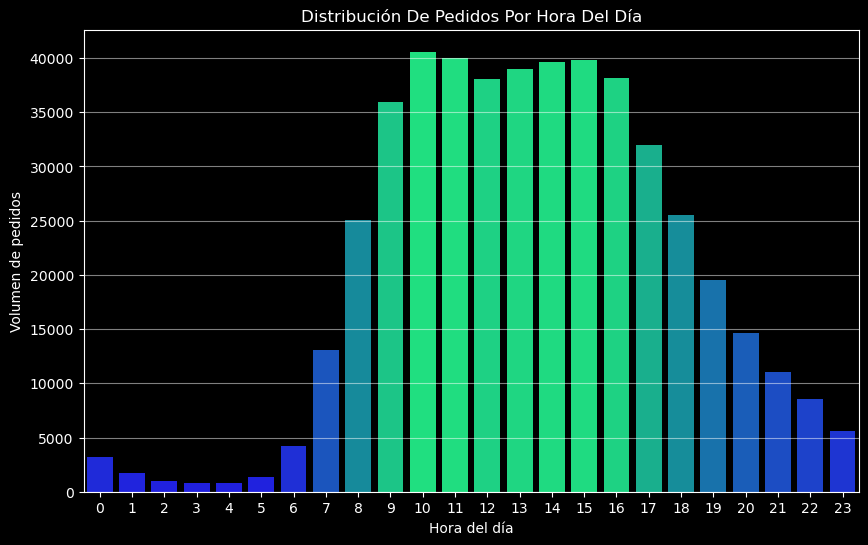

In [29]:
# Contamos la cantidad de ordenes por hora del día
oders_by_hour =df_insta_orders.groupby('order_hour_of_day')['order_hour_of_day'].count()

# Hacemos un gráfico de barras para la cantidad de ordenes por hora del día
plt.figure(figsize=(10,6))
sns.barplot(x=oders_by_hour.index,
            y=oders_by_hour.values,
            hue=oders_by_hour.values,
            palette='winter',
            legend=False
            )
plt.grid(axis='y', alpha=0.5)
plt.title('Distribución de pedidos por hora del día'.title())
plt.xlabel('Hora del día')
plt.ylabel('Volumen de pedidos')
plt.show()

Tras modelar el volumen de transacciones por hora, se identifica un comportamiento bimodal con una clara dominancia en el horario diurno. Los hallazgos principales son:

* ⚡ Meseta de Máxima Demanda (Picos Operativos): Se observa una ventana de alta intensidad entre las 09:00 y las 16:00 horas, con un volumen sostenido superior a los 35,000 pedidos. El pico máximo absoluto ocurre a las 10:00 AM, consolidándose como la hora crítica para la logística y disponibilidad de la plataforma.

* 🌅 Fase de Aceleración Matutina: A partir de las 07:00 AM, el sistema experimenta un incremento exponencial en la tasa de pedidos, marcando el inicio de la jornada operativa principal y sugiriendo un hábito de compra ligado al inicio de las actividades diarias de los usuarios.

* 📉 Desaceleración y Comportamiento Nocturno: Se detecta un descenso progresivo después de las 17:00 horas. La actividad durante la madrugada (00:00 - 06:00) es estadísticamente marginal, confirmando que el servicio tiene un uso casi exclusivamente diurno.

💡 Insight Estratégico: La concentración del 70% de la carga operativa en un bloque de 7 horas sugiere la necesidad de optimizar la asignación de repartidores y el soporte técnico durante este intervalo para mitigar posibles cuellos de botella.

## 3.03. 📅 Estacionalidad Semanal de la Demanda: Hábitos de Reabastecimiento

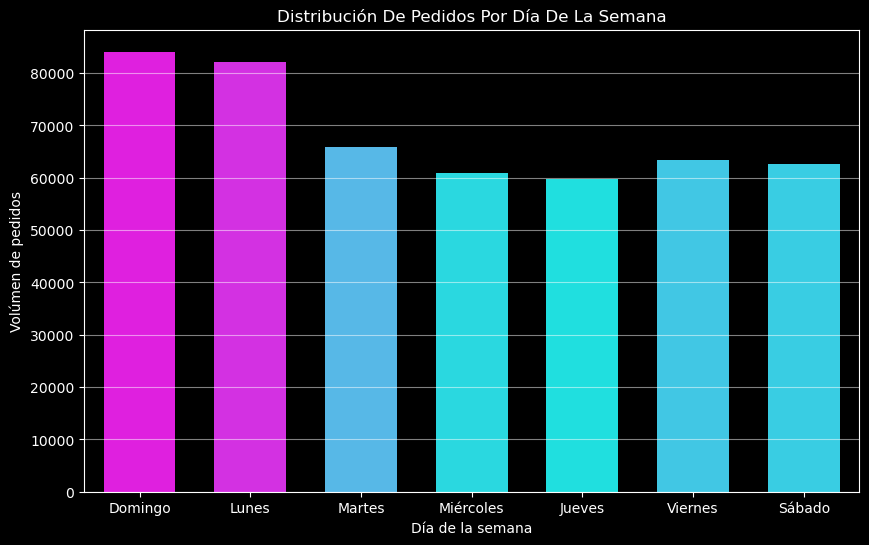

Domingo      84090
Lunes        82185
Martes       65833
Miércoles    60897
Jueves       59810
Viernes      63488
Sábado       62649
Name: order_dow, dtype: int64


In [30]:
# Contamos la cantidad de ordenes por día de la semana
bar_insta_orders = df_insta_orders.groupby('order_dow')['order_dow'].count()
bar_insta_orders.index = ['Domingo', 'Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado']

# Hacemos un gráfico de barras para la cantidad de ordenes por hora del día
plt.figure(figsize=(10,6))
sns.barplot(x=bar_insta_orders.index,
            y=bar_insta_orders.values,
            hue=bar_insta_orders.values,
            palette='cool',
            legend=False,
            width=0.65
            )
plt.grid(axis='y', alpha=0.5)
plt.title('Distribución de pedidos por día de la semana'.title())
plt.xlabel('Día de la semana')
plt.ylabel('Volúmen de pedidos')
plt.show()

print(bar_insta_orders)

El análisis de volumen por día de la semana (**order_dow**) revela una concentración de demanda muy marcada en el inicio del ciclo semanal. Los hallazgos principales son:

* 🚀 **Pico de Alta Demanda (Fase de Reabastecimiento)**: El **domingo (84,090 órdenes)** y el **lunes (82,185 órdenes)** se consolidan como los días de mayor actividad transaccional. Este comportamiento sugiere que el usuario promedio de Instacart utiliza la plataforma como su herramienta principal para la planificación y compra de la despensa semanal.

* 📉 **Fase de Estabilización (Valle Semanal)**: A partir del martes, se observa una contracción en el volumen de pedidos, alcanzando su punto mínimo el **jueves (59,810 órdenes)**. Este descenso representa una caída del **28.8%** respecto al pico del domingo, marcando la ventana de menor presión operativa para la logística de entrega.

* 📈 **Recuperación de Fin de Semana**: Se detecta un repunte moderado a partir del viernes y sábado, estabilizándose por encima de las 62,000 órdenes. Esto indica una transición hacia compras de conveniencia o preparación para el fin de semana antes del gran ciclo de reabastecimiento del domingo.

💡 **Insight de Negocio**: La disparidad de volumen entre el domingo y el jueves sugiere una oportunidad para implementar estrategias de **"Dynamic Pricing"** o promociones exclusivas en días de baja demanda (miércoles/jueves) para balancear la carga operativa de los repartidores a lo largo de la semana.

## 3.04. 🔄 Dinámica de Retención: Análisis del Ciclo de Reabastecimiento

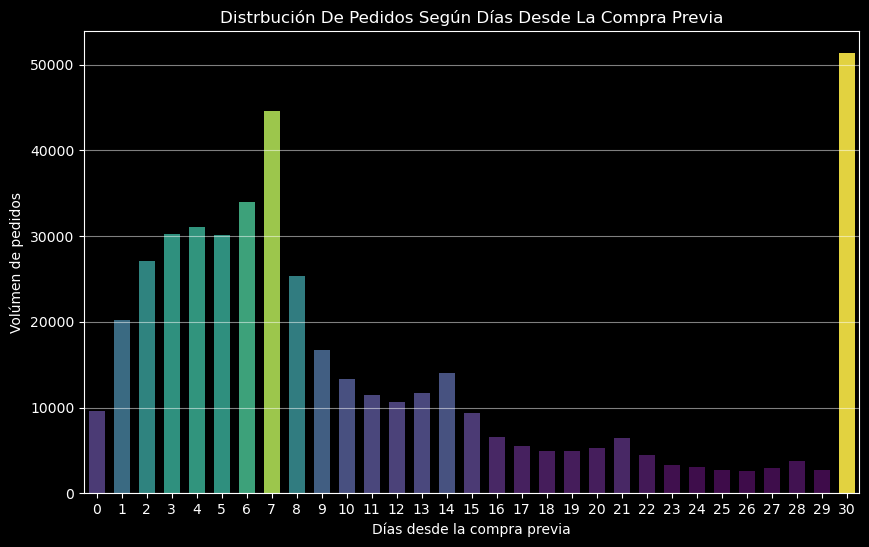

Estadísticas descriptivas de la Cantidad de días sin hacer ordenes:


,days_since_prior_order
count,450135.000000
mean,11.101814
std,9.190004
min,0.000000
25%,4.000000
50%,7.000000
75%,15.000000
max,30.000000


In [31]:
# Contamos 'la cantidad de ordenes' VS 'días sin hacer ordenes'
bar_2 = df_insta_orders.groupby('days_since_prior_order')['days_since_prior_order'].count()
bar_2.index =bar_2.index.astype('int')

# Hacemos un gráfico de barras para 'la cantidad de ordenes' VS 'días sin hacer ordenes'
plt.figure(figsize=(10,6))
sns.barplot(x=bar_2.index,
            y=bar_2.values,
            hue=bar_2.values,
            palette='viridis',
            legend=False,
            width=0.65
            )
plt.grid(axis='y', alpha=0.5)
plt.title('Distrbución de pedidos según días desde la compra previa'.title())
plt.xlabel('Días desde la compra previa')
plt.ylabel('Volúmen de pedidos')
plt.show()

# Estadisticas Descriptivas de la Cantidad de días sin hacer ordenes
print('Estadísticas descriptivas de la Cantidad de días sin hacer ordenes:')
pd.DataFrame(df_insta_orders['days_since_prior_order'].describe())

El estudio de la variable days_since_prior_order permite cuantificar la lealtad y los hábitos de consumo cíclicos de la base de usuarios. Los hallazgos demuestran una estructura de comportamiento altamente predecible:

* 📅 El Ciclo Semanal (Pico de los 7 días): Se observa un pico dominante a los 7 días, lo que confirma que el hábito de consumo más fuerte es el reabastecimiento semanal. La mediana ($50\%$) coincide exactamente con este valor, indicando que la mitad de los usuarios recurrentes regresan antes de una semana.

* 📈 Picos Secundarios y Periodicidad: Existe una clara presencia de picos menores a los 14 y 21 días. Estos "ecos" estadísticos sugieren segmentos de usuarios con ciclos de compra quincenales o dependientes de periodos de pago.

* 🚩 Análisis del Límite Operativo (Día 30): El volumen máximo absoluto se concentra en el día 30. No obstante, este valor debe interpretarse con cautela: estadísticamente representa un punto de acumulación (censura a la derecha). Es altamente probable que el sistema de Instacart agrupe a todos los usuarios con más de 30 días de inactividad en esta categoría, funcionando como un indicador de usuarios en riesgo de fuga (churn).

* 📉 Valores Mínimos y Frecuencia: La presencia de pedidos en el día 0 indica compras inmediatas de conveniencia o correcciones de órdenes previas, aunque representan una fracción mínima de la población.

💡 Insight de Fidelización: Los usuarios que superan el umbral de los 7-10 días sin recompra entran en una zona de "enfriamiento". Las campañas de re-engagement deberían activarse preventivamente en el día 6 para capitalizar la inercia del hábito semanal detectado.

## 3.05. ⚖️ Comparativa de Dinámicas: Miércoles vs. Sábado

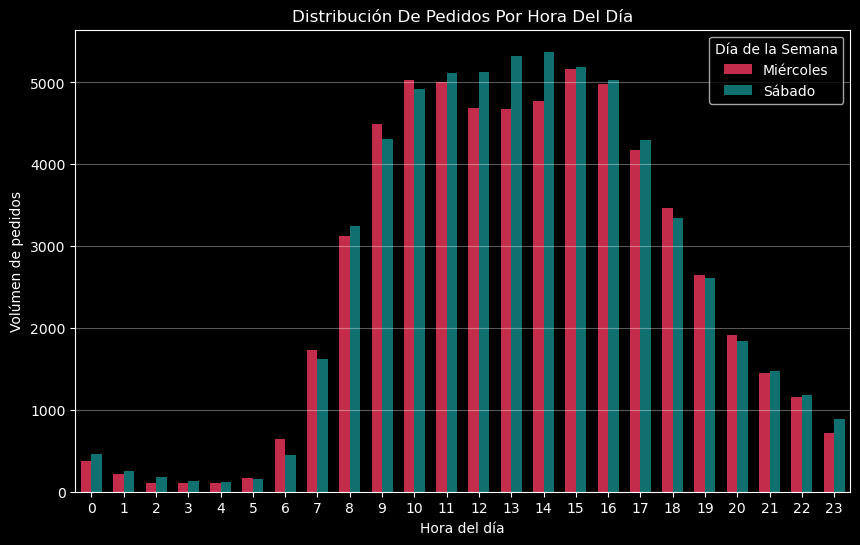

Estadísticas descriptivas de la hora del día para el miércoles y el sábado


,count,mean,std,min,25%,50%,75%,max
Miércoles,60897.0,13.531241,4.258216,0.0,10.0,13.0,17.0,23.0
Sábado,62649.0,13.536050,4.263393,0.0,10.0,13.0,16.0,23.0


In [32]:
# Elegimos el Míercoles y el Sábado
dow = ['Miércoles','Sábado']


norder = df_insta_orders.groupby(['order_dow', 'order_hour_of_day'])['order_hour_of_day'].count()
norder.name = 'count'
norder = norder.reset_index()

# Contamos la cantidad de ordenes para cada hora del día
norder = df_insta_orders.groupby(['order_dow', 'order_hour_of_day'])['order_hour_of_day'].count()
norder.name = 'count'
norder = norder.reset_index()
norder['order_dow'] = norder['order_dow'].replace({3:'Miércoles',6:'Sábado'})

# Hacemos un gráfico de barras para la cantidad de ordenes para cada hora del día
plt.figure(figsize=(10,6))
sns.barplot(data=norder.query('order_dow in @dow').rename(columns={'order_dow':'Día de la Semana'}),
            x='order_hour_of_day',
            y='count',
            hue='Día de la Semana',
            palette=['crimson','teal'],
            width=0.65
            )
plt.grid(axis='y', alpha=0.35)
plt.title('Distribución de pedidos por hora del día'.title())
plt.xlabel('Hora del día')
plt.ylabel('Volúmen de pedidos')
plt.show()

# Estadísticas descriptivas de la hora del día para el miércoles y el sábado
print('Estadísticas descriptivas de la hora del día para el miércoles y el sábado')
dow = [3,6]
pd.DataFrame([df_insta_orders.query('order_dow == 3')['order_hour_of_day'].describe().values, 
              df_insta_orders.query('order_dow == 6')['order_hour_of_day'].describe().values],
             index=['Miércoles','Sábado'],
             columns=df_insta_orders.query('order_dow in @dow')['order_hour_of_day'].describe().index)

Para entender si los hábitos de compra varían según el contexto semanal (laboral vs. ocio), se contrastaron las distribuciones horarias del miércoles y el sábado. Los hallazgos muestran una **homogeneidad inesperada**:

* 📊 **Simetría en la Distribución**: A pesar de la diferencia en la percepción del tiempo de los usuarios en estos días, las medidas de tendencia central son virtualmente idénticas ($\mu \approx 13.53$ hrs para ambos). Esto indica que el comportamiento de compra en Instacart es un hábito anclado a horarios fijos, independientemente de si es un día de semana o fin de semana.

* 📉 **Análisis de Desviación**: Con una desviación estándar de $\approx 4.26$ en ambos casos, la dispersión de las órdenes sigue un patrón de campana muy similar, concentrando el grueso de la operación en el mismo intervalo diurno.

* 🔎 **Micro-variaciones**: 

    * **Miércoles**: Se observa una ligera ventaja en el volumen durante las primeras horas de la mañana (10:00).

    * **Sábado**: Muestra una mayor resiliencia en la tarde (13:00 - 15:00), lo que podría asociarse a compras de preparación para eventos sociales o descanso dominical.

💡 **Conclusión Técnica**: La plataforma puede aplicar las mismas estrategias de escalamiento logístico para ambos días. No existe un "desplazamiento horario" significativo que justifique cambios en los turnos de los repartidores entre un miércoles y un sábado.

## 3.06. 👥 Estructura de Fidelidad: Distribución de Pedidos por Cliente

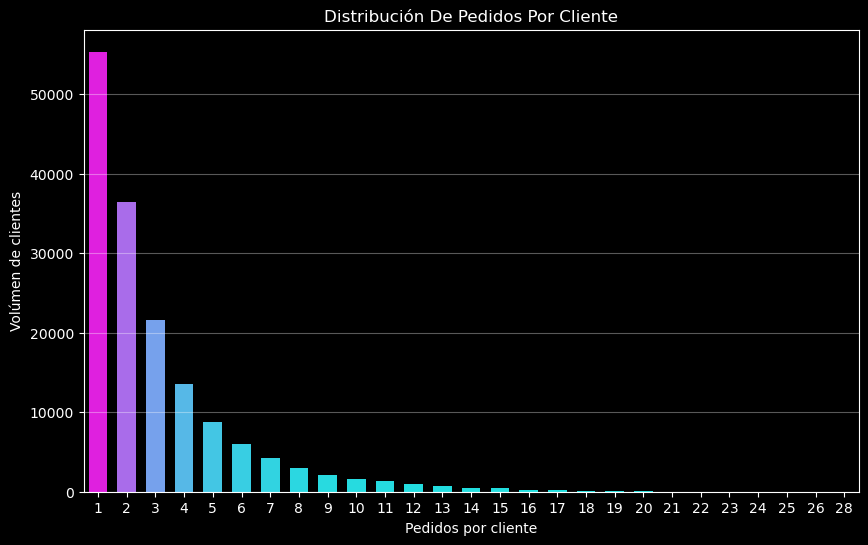

Estadísticas descriptivas de la cantidad de ordenes por cliente
       orders_per_client
count      157437.000000
mean            3.042182
std             2.746842
min             1.000000
25%             1.000000
50%             2.000000
75%             4.000000
max            28.000000


In [33]:
# Contamos la cantidad de ordenes por cliente y el número de clientes para cada cantidad de ordenes
orders_per_client = df_insta_orders.groupby('user_id')['order_id'].count()
dist_per_clients = pd.DataFrame(orders_per_client.value_counts()).rename(columns={'count': 'clients'})
dist_per_clients.index.name='orders_per_client'

# Hacemos un gráfico de barras para la cantidad de ordenes por cliente y el número de clientes para cada cantidad de ordenes
plt.figure(figsize=(10,6))
sns.barplot(data=dist_per_clients.reset_index(),
            x='orders_per_client',
            y='clients',
            hue='clients',
            legend=False,
            palette='cool',
            width=0.65
            )
plt.grid(axis='y', alpha=0.35)
plt.title('Distribución de pedidos por cliente'.title())
plt.xlabel('Pedidos por cliente')
plt.ylabel('Volúmen de clientes')
plt.show()

# Estadísticas descriptivas de la cantidad de ordenes por cliente
print('Estadísticas descriptivas de la cantidad de ordenes por cliente')
print(pd.DataFrame(orders_per_client).rename(columns={'order_id': 'orders_per_client'}).describe())

El análisis de la frecuencia de compra por usuario único permite entender la penetración de la plataforma y el nivel de retención. Los datos revelan una base de usuarios con las siguientes características:

* 📈 **Dominancia de Nuevos Usuarios (Adquisición)**: El volumen más alto de clientes se concentra en **1 solo pedido (55,000+ usuarios)**. Esto indica una etapa de fuerte adquisición de usuarios, pero también resalta el reto de convertirlos en compradores recurrentes.

* 📊 **Medidas de Tendencia Central**: El promedio de órdenes por cliente es de $\approx 3.04$, mientras que la mediana se sitúa en 2.0. Esta diferencia entre la media y la mediana confirma un sesgo a la derecha; es decir, un grupo selecto de usuarios frecuentes está elevando el promedio general.

* 🐉 **La "Larga Cola" (Power Users)**: Aunque la frecuencia decae rápidamente, existe un segmento de clientes leales que han realizado hasta **28 pedidos**. Estos "Power Users" representan el activo más valioso para la estabilidad de ingresos de la plataforma, a pesar de ser una minoría estadística.

* 📉 **Tasa de Abandono Temprano**: Se observa una caída pronunciada entre el primer y el segundo pedido. El 75% de los clientes han realizado 4 pedidos o menos, lo que sugiere que los primeros 3 contactos con el servicio son críticos para asegurar la retención a largo plazo.

💡 **Insight de Marketing**: Existe una oportunidad masiva en la conversión de usuarios de "un solo uso" hacia el segundo y tercer pedido. Implementar programas de **lealtad o cupones de retención** tras la primera compra podría desplazar la mediana hacia la derecha y aumentar el Life Time Value (LTV) promedio.

## 3.07. 🍌 Análisis de Popularidad: El Top 20 de Productos

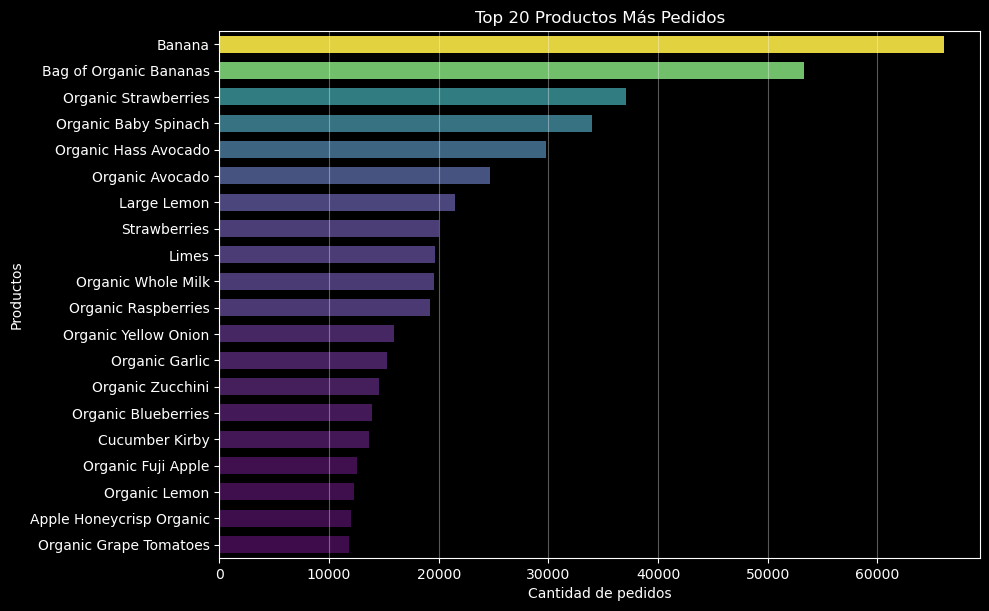

In [34]:
# Agrupamos por 'product_id' y contamos la cantidad de 'order_id' para cada producto. Ordenamos los valores de forma descendente y seleccionamos los 20 productos con más pedidos.
top_20_id = pd.DataFrame(df_order_prod.groupby('product_id')['order_id'].count().sort_values(ascending=False).head(20))

# Creamos un DataFrame con los IDs de los 20 productos más pedidos.
top_20 = pd.DataFrame(top_20_id.index)

# Realizamos un merge entre el DataFrame de los 20 productos más pedidos y el DataFrame de productos para obtener los nombres de los productos.
top_20 = pd.merge(top_20, df_products, on='product_id', how='left')

# Creamos una nueva columna llamada 'orders' con la cantidad de pedidos para cada producto.
top_20['orders'] = top_20_id.values

# Hacemos un gráfico de barras para la cantidad de pedidos por producto para los 20 productos más pedidos
plt.figure(figsize=(10,6))
sns.barplot(data=top_20,
            y='product_name',
            x='orders',
            hue='orders',
            legend=False,
            palette='viridis',
            width=0.65
            )
plt.tight_layout()
plt.grid(axis='x', alpha=0.35)
plt.title('Top 20 Productos Más Pedidos'.title())
plt.xlabel('Cantidad de pedidos')
plt.ylabel('Productos')
plt.show()

El ranking de los productos más vendidos revela una radiografía clara de las prioridades del consumidor de Instacart. La visualización permite extraer las siguientes conclusiones estratégicas:

* 🥇 **Hegemonía del "Banana"**: El producto estrella indiscutible es el plátano (Banana), ocupando las dos primeras posiciones del ranking (convencional y orgánico) con más de **110,000 pedidos combinados**. Este es un fenómeno común en e-commerce de víveres, donde el plátano actúa como el "artículo de anclaje" de la mayoría de las cestas.

* 🌿 **Dominio de lo Orgánico**: Es impactante notar que el **75% de los productos (15 de 20)** en el top incluyen la etiqueta "Organic". Desde fresas y espinacas hasta aguacates y limones, el consumidor muestra una disposición sistémica a pagar por categorías percibidas como más saludables.

* 🥗 **Perfil de Cesta "Fresh-First"**: El Top 20 está compuesto casi exclusivamente por **productos frescos y perecederos** (frutas, verduras y lácteos). No aparecen productos procesados ni de larga duración en este segmento de élite, lo que posiciona a Instacart como una plataforma de reabastecimiento de alimentos frescos en lugar de una despensa de artículos de limpieza o enlatados.

* 🥑 **El Aguacate como Producto Premium**: Tanto el Organic Hass Avocado como el Organic Avocado ocupan puestos de alta relevancia, confirmando su estatus como un componente esencial en la dieta de los usuarios de alto valor de la plataforma.

💡 **Insight de Inventario**: Dado que el Top 20 está dominado por perecederos, la eficiencia en la **cadena de frío y la gestión de mermas** es el pilar crítico para la rentabilidad. Cualquier optimización en la logística de estos 20 productos tendrá un impacto masivo en la satisfacción del cliente.

 ## 3.08. 🛒 Análisis de Densidad de Cesta: Composición por Pedido

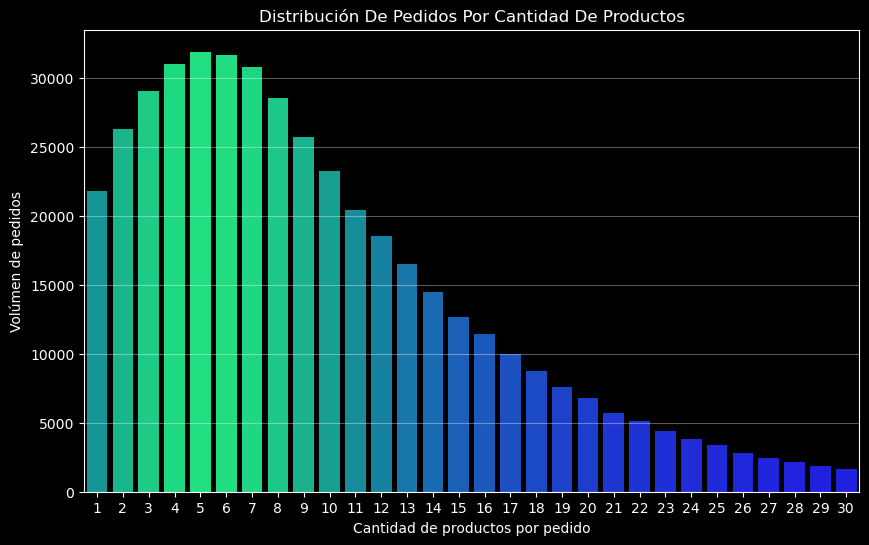

Estadísticas descriptivas de la cantidad de productos por pedido


,number_of_products_per_order
count,450046.000000
mean,10.098983
std,7.540206
min,1.000000
25%,5.000000
50%,8.000000
75%,14.000000
max,127.000000


In [35]:
# Agrupamos por 'order_id' y contamos la cantidad de 'product_id' para cada pedido. 
# Luego contamos la cantidad de pedidos para cada cantidad de productos por pedido, 
# ordenamos los valores por el índice y lo guardamos en un nuevo DataFrame.
# Finalmente, obtenemos el número de productos por pedido y el número de pedidos para cada cantidad de productos por pedido.
qorder_vs_qproducts = pd.DataFrame(df_order_prod.groupby('order_id')['product_id'].count().value_counts().sort_index())
qorder_vs_qproducts.index.name='number_of_products_per_order'
qorder_vs_qproducts.rename(columns={'count': 'number_of_orders'}, inplace=True)
qorder_vs_qproducts.reset_index(inplace=True)

# Gráficamos la distribución de la cantidad de productos por pedido.
plt.figure(figsize=(10,6))
sns.barplot(data=qorder_vs_qproducts.head(30),
            x='number_of_products_per_order',
            y='number_of_orders',
            hue='number_of_orders',
            palette='winter',
            legend=False
            )
plt.grid(axis='y', alpha=0.35)
plt.title('Distribución de pedidos por cantidad de productos'.title())
plt.xlabel('Cantidad de productos por pedido')
plt.ylabel('Volúmen de pedidos')
plt.show()

# Estadísticas descriptivas de la cantidad de productos por pedido
print('Estadísticas descriptivas de la cantidad de productos por pedido')
pd.DataFrame(df_order_prod.groupby('order_id')['product_id'].count()).rename(columns={'product_id':'number_of_products_per_order'}).describe()

 El estudio del volumen de artículos por transacción permite entender el uso que el cliente le da a la plataforma (¿compras de conveniencia o abastecimiento total?). Los datos revelan una distribución asimétrica con una "larga cola":
 
 * 📦 **El "Sweet Spot" del Carrito**: La mayoría de los pedidos se concentran en un rango de **3 a 7 productos**, alcanzando su moda (el punto más alto) en los **5 artículos**. Esto sugiere que una gran parte de las transacciones son compras de reposición rápida o categorías específicas.

* 📊 **Tendencia Central y Dispersión**: El promedio se sitúa en $\approx 10$ artículos, pero la mediana ($50\%$) es de 8. Esta discrepancia, sumada a una desviación estándar de $7.5$, indica que aunque los carritos pequeños son más frecuentes, hay una presencia constante de pedidos medianos y grandes que elevan el ticket promedio.

* 🐉 **Carritos de Volumen Extremo**: Se observa una extensión de la distribución que llega hasta un máximo de **127 productos**. Es aquí donde residen los datos que anteriormente identificamos con el marcador `999` (aquellos que superaron la posición 64), representando a las familias o clientes institucionales que realizan compras masivas.

* 📉 **Compras de Conveniencia Única**: Un volumen considerable de usuarios realiza pedidos de un solo artículo ($n=1$), lo cual resalta la importancia de la logística de "última milla" para artículos de urgencia.

💡 **Insight Logístico**: Con el 75% de las órdenes conteniendo 14 productos o menos, la operación de picking (recolección en tienda) es altamente eficiente para pedidos pequeños. Sin embargo, el segmento de carritos con $>30$ productos requiere una gestión de transporte distinta para asegurar la integridad de los productos frescos detectados en el Top 20.

 ## 3.09. 🔄 Análisis de Reincidencia: El Top 20 de Productos con Mayor Retención

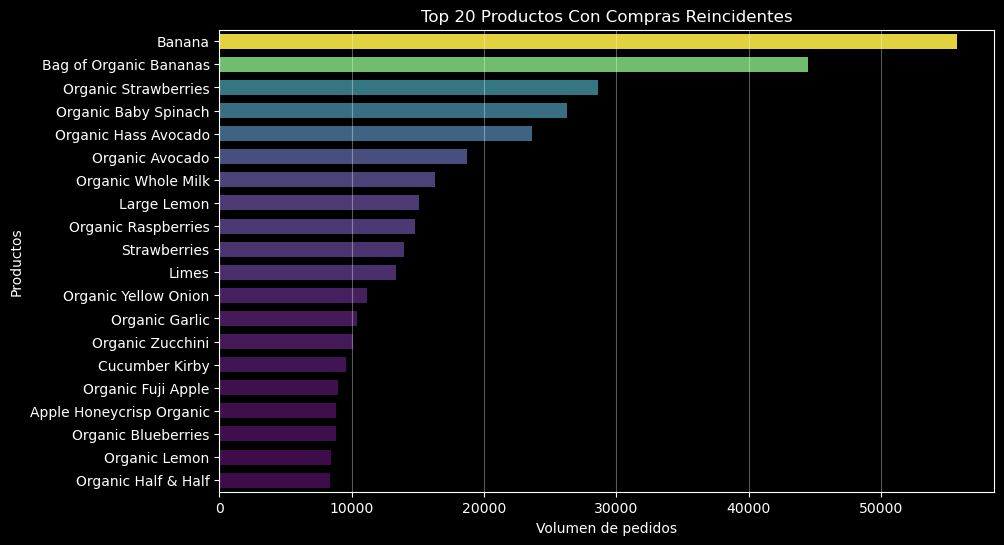

In [36]:
# Primero seleccionamos únicamente los productos que fueron reordenados,
# luego agrupamos por producto y contamos la cantidad de ordenes para cada producto.
# Luego ordenamos los valores de forma descendente y seleccionamos los 20 productos con más pedidos reordenados.
top_20_reord = pd.DataFrame(df_order_prod[df_order_prod['reordered']==1].groupby('product_id')['order_id'].count().sort_values(ascending=False)).reset_index().rename(columns={'order_id':'orders'})
top_20_reord = pd.merge(top_20_reord, df_products, on='product_id', how='left')
top_20_reord = top_20_reord.iloc[:,[0, 2, 1]]

# Gráficamos la distribución de pedidos por producto para los 20 productos más pedidos con compras reincidentes.
plt.figure(figsize=(10,6))
sns.barplot(data=top_20_reord.head(20),
            y='product_name',
            x='orders',
            hue='orders',
            palette='viridis',
            legend=False,
            width=0.65
            )
plt.grid(axis='x', alpha=0.35)
plt.title('Top 20 productos con compras reincidentes'.title())
plt.xlabel('Volumen de pedidos')
plt.ylabel('Productos')
plt.show()

Identificar los artículos que los usuarios vuelven a solicitar de forma recurrente permite descifrar los "básicos" indispensables del hogar. Al analizar este segmento, observamos una consistencia casi perfecta con el volumen total de ventas, pero con matices interesantes:

* 👑 **Los "Indispensables" del Inventario**: Nuevamente, la **Banana** y la **Bag of Organic Bananas** lideran el ranking. Su altísima tasa de reincidencia confirma que son productos de consumo diario y vida útil corta, lo que obliga al usuario a reponerlos en casi cada ciclo de compra (cada 7 días, como vimos en el análisis de recurrencia).

* 🧬 **Consistencia en el Perfil Orgánico**: Existe una correlación casi total entre el volumen de ventas y la reincidencia. Los productos orgánicos (fresas, espinacas, aguacates) no solo son los más comprados, sino los que presentan mayor fidelidad. Esto sugiere que el consumidor de productos orgánicos en Instacart es un **perfil de cliente recurrente**, no ocasional.

* 🥛 **La Entrada de los Lácteos**: Un hallazgo relevante en este Top es la posición de la **Organic Whole Milk** y la **Organic Half & Half**. A diferencia de otros productos que podrían ser compras impulsivas, los lácteos son marcadores de lealtad: una vez que el cliente elige una marca o tipo de leche, tiende a automatizar su compra en pedidos subsecuentes.

* 🍏 **Estabilidad de la Dieta**: La presencia de frutas como la Organic Fuji Apple y el Honeycrisp Organic indica que el usuario utiliza la plataforma para mantener hábitos alimenticios estables.

💡 **Insight de Retención**: Los productos en esta lista son los "anclas" de la aplicación. Si un cliente encuentra su marca favorita de leche o la calidad de sus bananas siempre disponible, la probabilidad de que realice su próximo pedido (el salto crítico de la compra 1 a la 2 que analizamos antes) aumenta exponencialmente.

## 3.10. 📦 Arquitectura del Consumo: Distribución y Dominancia por Departamento

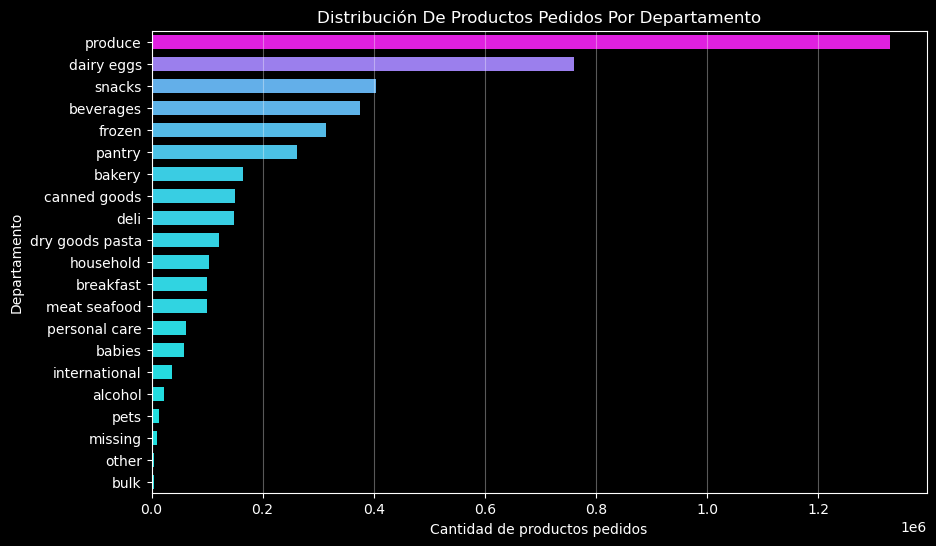

In [37]:
# Contamos la cantidad d productos vendidos por departamento y graficamos la distribución de productos pedidos por departamento
plt.figure(figsize=(10, 6))
departments_dist = df_order_prod.merge(df_products[['product_id', 'department_id']], 
                    on='product_id', 
                    how='left').merge(df_departments, 
                                      on='department_id', 
                                      how='left')['department'].value_counts()
sns.barplot(x=departments_dist.values,
            y=departments_dist.index,
            hue=departments_dist.values,
            palette='cool',
            legend=False,
            width=0.65
            )
plt.grid(axis='x', alpha=0.35)
plt.title('Distribución de productos pedidos por departamento'.title())
plt.xlabel('Cantidad de productos pedidos')
plt.ylabel('Departamento')
plt.show()

Entender la macro-estructura de los pedidos permite identificar qué categorías sostienen la operación logística y cuáles son los verdaderos "imanes" de tráfico. Al analizar el volumen total por departamento, la jerarquía del sistema se revela con total claridad:

* 🌽 El "Core" de Alta Frecuencia: El departamento de Produce (frutas y verduras) no solo lidera, sino que duplica en volumen al segundo lugar. Esta dominancia absoluta confirma que Instacart es, ante todo, una herramienta de reabastecimiento de frescos. Para el negocio, esto significa que la calidad percibida en este departamento define la retención del cliente: si el aguacate llega mal, se pierde la confianza en todo el carrito.

* 🥛 Lácteos y Huevos como Pilares: Dairy Eggs ocupa el segundo puesto con una solidez notable. Al igual que las bananas en el análisis de productos, estos son artículos de "consumo invisible" pero constante. Son productos con una ventana de caducidad media, lo que refuerza la teoría de los ciclos de compra semanales (7 días) que observamos previamente.

* 🥤 La Capa de Conveniencia: Los departamentos de Snacks y Beverages completan el grupo de cabeza. A diferencia de los perecederos, estos productos tienen márgenes de ganancia más altos y una vida útil prolongada. Su alta presencia sugiere que, una vez que el usuario entra por los básicos (frutas/leche), tiende a completar su canasta con artículos de conveniencia, lo que eleva el valor del ticket promedio.

* 🧼 Segmentos de Especialidad y "Long-Tail": Departamentos como Personal Care, Babies o Pets muestran volúmenes significativamente menores. Esto indica que el usuario promedio aún no utiliza la plataforma para compras integrales de "tienda departamental", sino que mantiene una fidelidad selectiva. Aquí reside la mayor oportunidad de crecimiento mediante estrategias de cross-selling.

💡 Insight de Operación: La logística de Instacart es, esencialmente, una cadena de frío y frescos. Más del 60% de la operación se concentra en departamentos con productos sensibles a la temperatura y al tiempo. Cualquier optimización en la ruta de entrega o en el proceso de selección (picking) en estas categorías tendrá un impacto desproporcionado en la rentabilidad y satisfacción final.

 ## 3.11. 📈 Análisis de Fidelidad: Razón de Recompra por Producto

             product_name  razon_recompra
0                  Banana        0.844254
1  Bag of Organic Bananas        0.834006
2    Organic Strawberries        0.773212
3    Organic Baby Spinach        0.772217
4    Organic Hass Avocado        0.793639



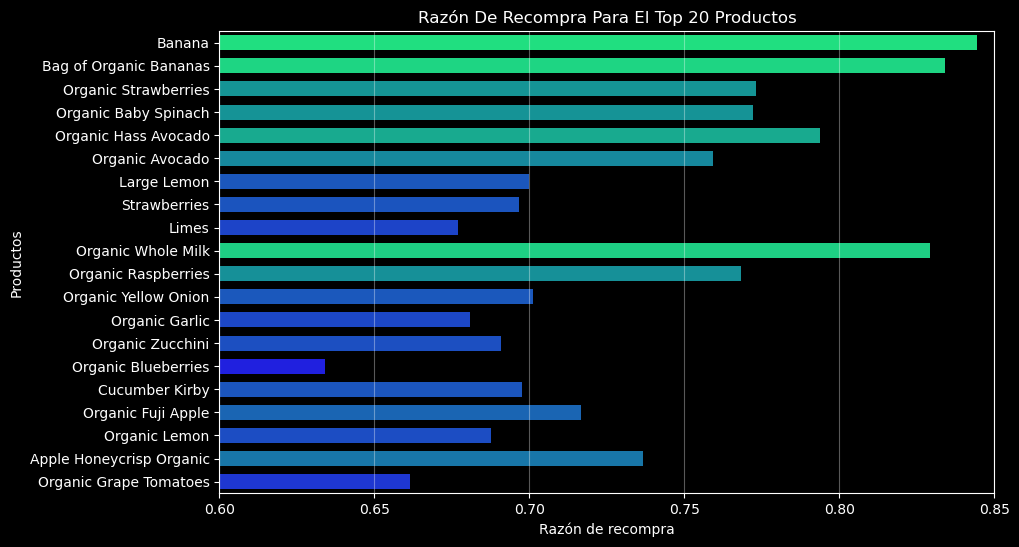

Porcentaje de recompra del Top 20: 76.02%
Porcentaje de recompra del resto: 18.75%
Porcentaje total de recompra: 59.05%


In [38]:
# Agrupamos por 'product_id' y contamos la cantidad de 'order_id' para cada producto,
# pero esta vez lo hacemos para los productos reordenados y no reordenados.
reordered_vs_non = pd.pivot_table(df_order_prod, index=['product_id'], columns=['reordered'], values='order_id', aggfunc='count')

# Rellenamos los valores ausentes con 0, 
# ya que si no hay un valor para un producto en la columna de reordenados o no reordenados, 
# significa que ese producto no tiene pedidos en esa categoría.
reordered_vs_non.fillna(0, inplace=True)

# Calculamos el total de pedidos para cada producto sumando los pedidos reordenados y no reordenados.
reordered_vs_non['total'] = (reordered_vs_non[0] + reordered_vs_non[1])

# Calculamos la razón de recompra dividiendo los pedidos reordenados entre el total de pedidos para cada producto.
reordered_vs_non['razon_recompra'] = reordered_vs_non[1]/reordered_vs_non['total']
reordered_vs_non.reset_index(inplace=True)

# Realizamos un merge entre el DataFrame de pedidos reordenados y no reordenados y el DataFrame de productos para obtener los nombres de los productos.
reordered_vs_non = pd.merge(reordered_vs_non, df_products[['product_id', 'product_name']], how='left', on='product_id')
reordered_vs_non.sort_values(['total', 'razon_recompra'], ascending=False, inplace=True)
reordered_vs_non.reset_index(inplace=True, drop=True)

# Creamos una nueva columna llamada 'top' que clasifica los productos en 10 grupos, cada grupo representa un decil de la contribución acumulada al total de pedidos.
n_divisones = 10
reordered_vs_non['top'] = ((reordered_vs_non['total'].cumsum()/reordered_vs_non['total'].sum())*n_divisones+1).astype('int').clip(1, n_divisones)
reordered_vs_non = reordered_vs_non.iloc[:,[0, 6, 5, 1, 2, 3, 4]]
print(reordered_vs_non[['product_name','razon_recompra']].head())
print()

# Gráficamos la razón de recompra para los 20 productos con más pedidos.
plt.figure(figsize=(10,6))
sns.barplot(data=reordered_vs_non.head(20),
            y='product_name',
            x='razon_recompra',
            hue='razon_recompra',
            palette='winter',
            legend=False,
            width=0.65
            )
plt.xlim(0.6, 0.85)
plt.grid(axis='x', alpha=0.35)
plt.title('Razón de recompra para el Top 20 productos'.title())
plt.xlabel('Razón de recompra')
plt.ylabel('Productos')
plt.show()

# Calculamos el porcentaje de recompra para el Top 20 productos, el resto de productos y el porcentaje total de recompra.
print(f'Porcentaje de recompra del Top 20: {reordered_vs_non.head(20)[1].sum()/reordered_vs_non.head(20)['total'].sum():.2%}')
print(f'Porcentaje de recompra del resto: {reordered_vs_non.iloc[20:,1].sum()/reordered_vs_non.iloc[20:,4].sum():.2%}')
print(f'Porcentaje total de recompra: {reordered_vs_non[1].sum()/reordered_vs_non['total'].sum():.2%}')

Más allá del volumen de ventas, la Razón de Recompra (proporción de pedidos que son reincidentes) nos indica qué productos son motores de retención. Los datos revelan una segmentación de lealtad extrema:

* 💎 **La Élite de la Retención (Top 20)**: Los 20 productos más populares presentan una razón de recompra impresionante del **76.02%**. Esto significa que 3 de cada 4 veces que uno de estos productos entra en un carrito, es porque el cliente ya lo ha comprado antes. La **Banana** ($84.4\%$) y la **Organic Whole Milk** ($82.9\%$) lideran este indicador de hábito.

* ⚠️ **La Brecha de Fidelidad**: Existe una diferencia crítica entre el Top 20 y el resto del catálogo. Mientras que los productos estrella retienen al cliente con un **76%**, el resto del catálogo apenas alcanza un **18.75%**. Esta brecha sugiere que la experiencia del usuario está fuertemente anclada a una "canasta básica" de alta calidad.

* 📊 **Promedio del Ecosistema**: La razón de recompra total del dataset es del **59.05%**. Un valor cercano al 60% es extremadamente alto para el sector de e-grocery, posicionando a la plataforma no como un sitio de descubrimiento, sino como un **servicio de infraestructura esencial** para el hogar.

* 🥗 **El Factor Orgánico como Retenedor**: Productos como el Organic Hass Avocado ($79.3\%$) demuestran que una vez que el usuario confía en la calidad de los frescos orgánicos, la probabilidad de abandono de esa categoría es mínima.

💡 **Insight de Crecimiento**: El negocio depende críticamente de la disponibilidad de estos 20 productos. Una rotura de stock (Out-of-stock) en bananas o leche orgánica no solo representa una venta perdida, sino el riesgo de romper el hábito de compra de un cliente que tiene un **80% de probabilidad de reincidencia**.

## 3.12. 📊 Segmentación por Deciles: La Anatomía de la Demanda

     count  razon_recompra
top                       
1       18        0.763433
2       55        0.679136
3      116        0.653865
4      222        0.624743
5      374        0.595975
6      631        0.578786
7     1086        0.556976
8     2030        0.532042
9     4596        0.497845
10   36445        0.424565


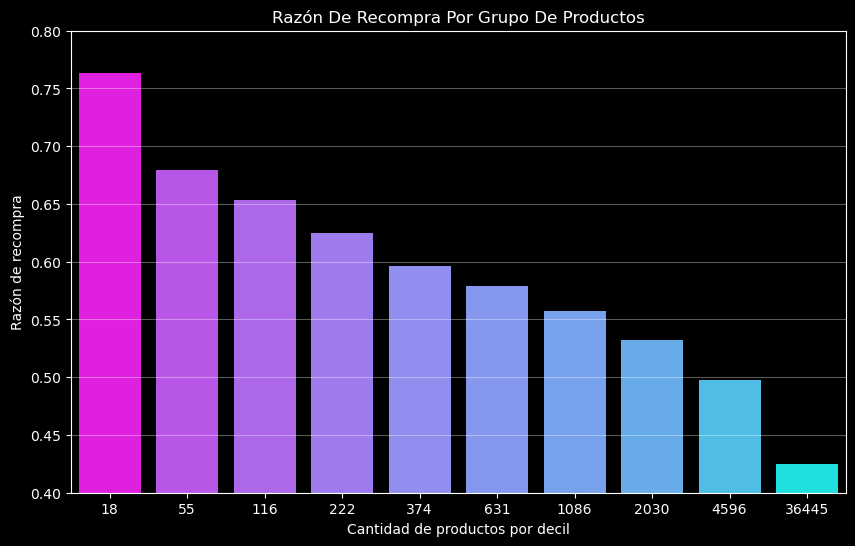

In [39]:
# Creamos un DataFrame que muestra la cantidad de productos en cada grupo de 'top'
rank_reordered_vs_non = pd.DataFrame(reordered_vs_non['top'].value_counts(ascending=True))

# Calculamos la razón de recompra para cada grupo de 'top' dividiendo la suma de pedidos reordenados entre la suma del total de pedidos para cada grupo.
razon_recompra =[]
for rank in range(1,n_divisones+1):
    razon_recompra.append(reordered_vs_non[reordered_vs_non['top'] == rank][1].sum()/reordered_vs_non[reordered_vs_non['top'] == rank]['total'].sum())
rank_reordered_vs_non['razon_recompra'] = razon_recompra
print(rank_reordered_vs_non)

# Gráficamos la razón de recompra para cada grupo de 'top'.
plt.figure(figsize=(10,6))
sns.barplot(data=rank_reordered_vs_non,
            x='count',
            y='razon_recompra',
            hue='razon_recompra',
            palette='cool',
            legend=False
            )
plt.ylim(0.4, 0.8)
plt.grid(axis='y', alpha=0.35)
plt.title('Razón de recompra por grupo de productos'.title())
plt.xlabel('Cantidad de productos por decil')
plt.ylabel('Razón de recompra')
plt.show()

Para entender la estructura del catálogo, se implementó una segmentación por deciles basada en el volumen de transacciones. Cada segmento representa exactamente el **10% del volumen total de ventas**, permitiendo contrastar la popularidad contra la lealtad (recompra).

1. 🎯 **Concentración Extrema de la Demanda (Efecto Pareto)**

    Los datos revelan una asimetría masiva en el rendimiento de los productos:

    * 💎 **La Élite del Catálogo (Decil 1)**: Únicamente **18 productos** (el $0.04\%$ del total) son responsables del primer $10\%$ de todas las ventas. Estos son los "motores" de la plataforma.

    * ⚖️ **Punto de Equilibrio ($50/1.7$)**: Los primeros 785 productos ($1.7\%$ del catálogo) generan más de la mitad del volumen transaccional.

    * 🏷️ **La "Larga Cola" (Decil 10)**: El último $10\%$ de las ventas está disperso entre 36,445 productos ($80\%$ del catálogo).

    * 🚀 **Diferencial de Velocidad**: Un producto del primer decil se vende, en promedio, 2,000 veces más que uno del último decil.

2. 🤝 **Correlación Volumen-Lealtad (Gradiente de Retención)**

    Se identificó que la popularidad no solo atrae volumen, sino que fomenta la lealtad:

    * 🧲 **Decil de Alta Fidelidad**: El primer decil presenta una razón de recompra del $76.3\%$, la más alta del sistema.

    * 📉 **Degradación Progresiva**: Existe un gradiente de lealtad decreciente de entre el $5\%$ y el $7\%$ por cada decil. A medida que un producto es menos popular, su probabilidad de ser vuelto a comprar cae drásticamente, llegando apenas al $42.4\%$ en el último decil.

💡 **Insight Estratégico**: El negocio posee un núcleo de "Ultra-Alta Rotación" extremadamente fiel. Mientras que el $80\%$ del catálogo (la Long Tail) ofrece variedad, el éxito operativo y la retención del usuario dependen casi exclusivamente del $2\%$ de los productos. Cualquier interrupción en la cadena de suministro de este núcleo tendría un impacto sistémico inmediato.

## 3.13. 👤 Análisis de Fidelidad por Usuario: El Cliente Recurrente

      order_product  razon_recompra
rank                               
1               580        0.822414
2               540        0.809259
3               526        0.844106
4               506        0.845850
5               504        0.890873
6               481        0.906445
7               480        0.804167
8               467        0.877944
9               458        0.877729
10              457        0.877462
11              448        0.921875
12              437        0.832952
13              427        0.833724
14              426        0.798122
15              425        0.842353
16              422        0.867299
17              411        0.749392
18              409        0.508557
19              406        0.889163
20              390        0.948718


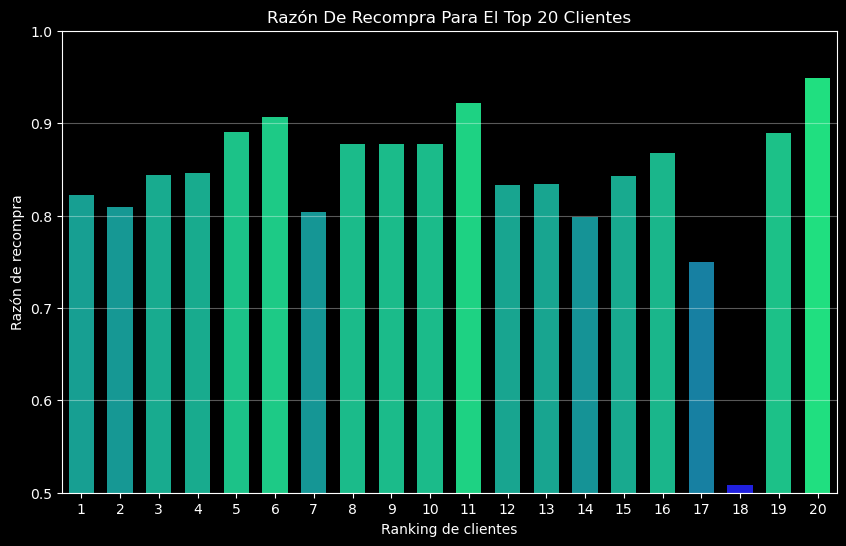

Porcentaje de recompra del Top 20: 83.85%
Porcentaje de recompra del resto: 59.00%
Porcentaje total de recompra: 59.05%


In [40]:
# Realizamos un merge para adjuntar el cliente a cada producto ordenado.
clients_reord = pd.merge(df_order_prod, df_insta_orders[['order_id', 'user_id']], on='order_id', how='left')

# Creamos una tabla pivote para contar la cantidad de pedidos reordenados y no reordenados para cada cliente.
clients_reord = pd.pivot_table(clients_reord, values='order_id', index='user_id', columns='reordered', aggfunc='count', fill_value=0)
clients_reord.columns.name = None

# Calculamos el total de pedidos para cada cliente sumando los pedidos reordenados y no reordenados.
clients_reord['order_product'] = clients_reord[0]+clients_reord[1]

# Calculamos la razón de recompra dividiendo los pedidos reordenados entre el total de pedidos para cada cliente.
clients_reord['razon_recompra'] = clients_reord[1]/clients_reord['order_product']
clients_reord.sort_values('order_product', inplace=True, ascending=False)
clients_reord.reset_index(inplace=True)
clients_reord.index = range(1,len(clients_reord.index.values)+1)
clients_reord.index.name = 'rank'

# Creamos una nueva columna llamada 'top' que clasifica a los clientes en 10 grupos, cada grupo representa un decil de la contribución acumulada al total de pedidos.
n_divisones = 10
cumsum_pct = clients_reord['order_product'].cumsum() / clients_reord['order_product'].sum()
clients_reord['top'] = ((cumsum_pct * n_divisones).astype(int) + 1).clip(1, n_divisones)
clients_reord = clients_reord.iloc[:,[5, 0, 1, 2, 3, 4]]
print(clients_reord[['order_product','razon_recompra']].head(20))

# Gráficamos la razón de recompra para los 20 clientes con más pedidos.
plt.figure(figsize=(10,6))
sns.barplot(data=clients_reord.head(20),
            x='rank',
            y='razon_recompra',
            hue='razon_recompra',
            palette='winter',
            legend=False,
            width=0.65
            )
plt.ylim(0.5, 1)
plt.grid(axis='y', alpha=0.35)
plt.title('Razón de recompra para el Top 20 clientes'.title())
plt.xlabel('Ranking de clientes')
plt.ylabel('Razón de recompra')
plt.show()

# Calculamos el porcentaje de recompra para el Top 20 clientes, el resto de clientes y el porcentaje total de recompra.
print(f'Porcentaje de recompra del Top 20: {clients_reord.head(20)[1].sum()/clients_reord.head(20)['order_product'].sum():.2%}')
print(f'Porcentaje de recompra del resto: {clients_reord.iloc[20:,3].sum()/clients_reord.iloc[20:,4].sum():.2%}')
print(f'Porcentaje total de recompra: {clients_reord[1].sum()/clients_reord['order_product'].sum():.2%}')

Se analizó la proporción de productos reincidentes a nivel de usuario. Los resultados permiten segmentar la base de clientes según su **índice de lealtad**:

* 💎 La Élite de Consumo (Top 20 Clientes): Los 20 clientes con mayor volumen de productos presentan una razón de recompra extraordinaria del **83.85%**. Para estos usuarios, Instacart no es un canal de descubrimiento, sino una herramienta de eficiencia donde repiten casi la totalidad de su canasta básica en cada pedido.

* 📈 Estabilidad en la Base General: Incluso fuera de la élite, el resto de los clientes mantiene una razón de recompra sólida del **59.00%**. Esta consistencia entre el promedio general ($59.05\%$) y la gran masa de usuarios indica que el hábito de "volver a pedir lo conocido" es una característica intrínseca de toda la plataforma.

* 🔎 Identificación de Casos Atípicos: En el Top 20, destaca el **Ranking 20** con la tasa de recompra más alta ($94.8\%$) y el **Ranking 18** como una anomalía estadística dentro del grupo ($50.8\%$). Este último representa a un cliente de gran volumen que aún está en fase de exploración de catálogo.

💡 Insight de Personalización: Con una tasa de recompra tan alta en los clientes de mayor valor, algoritmos de **"Compra Recurrente"** o recordatorios tipo **"¿Olvidaste añadir tus básicos?"** tendrían una efectividad teórica del 84%. El valor del negocio no está en vender cosas nuevas, sino en facilitar la reposición de lo habitual.

## 3.14. 👥 Segmentación de Clientes por Deciles: El Motor de la Recurrencia

     count  razon_recompra
top                       
1     2209        0.772777
2     3465        0.718506
3     4591        0.687348
4     5914        0.651553
5     7544        0.613278
6     9610        0.572429
7    12469        0.530605
8    16883        0.489788
9    24975        0.446475
10   61966        0.422281


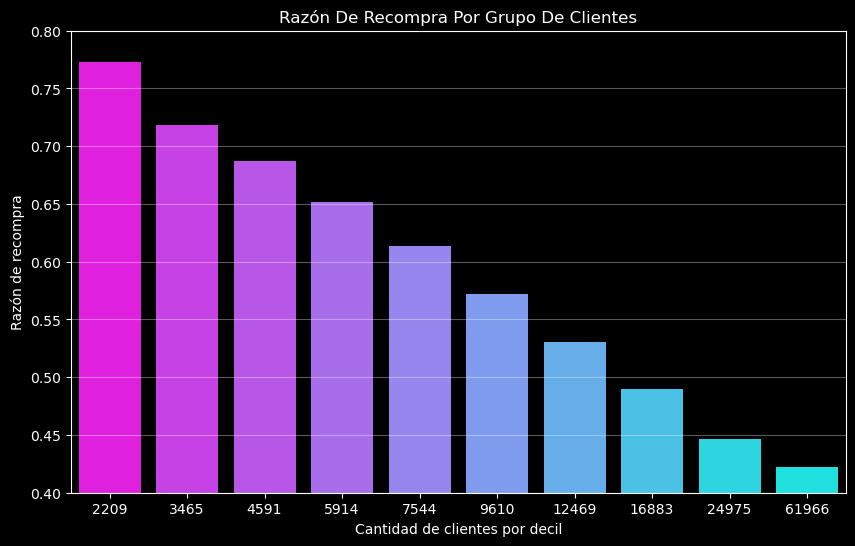

In [41]:
# Creamos un DataFrame que muestra la cantidad de clientes en cada grupo de 'top'
rank_clients_reord = pd.DataFrame(clients_reord['top'].value_counts(ascending=True))

# Calculamos la razón de recompra para cada grupo de 'top' dividiendo la suma de pedidos reordenados entre la suma del total de pedidos para cada grupo.
razon_recompra=[]
for indice in rank_clients_reord.index.values:
    razon_recompra.append(clients_reord[clients_reord['top'] == indice][1].sum()/clients_reord[clients_reord['top'] == indice]['order_product'].sum())
rank_clients_reord['razon_recompra'] = razon_recompra
print(rank_clients_reord)

# Gráficamos la razón de recompra para cada grupo de 'top'.
plt.figure(figsize=(10,6))
sns.barplot(data=rank_clients_reord,
            x='count',
            y='razon_recompra',
            hue='razon_recompra',
            palette='cool',
            legend=False
            )
plt.ylim(0.4, 0.8)
plt.grid(axis='y', alpha=0.35)
plt.title('Razón de recompra por grupo de clientes'.title())
plt.xlabel('Cantidad de clientes por decil')
plt.ylabel('Razón de recompra')
plt.show()

Se aplicó una división por deciles donde cada grupo representa el **10% del volumen total de artículos comprados**, permitiendo diseccionar la base de usuarios según su intensidad transaccional.

 1. 🎯 **Concentración de Usuarios de Alto Valor (VIPs)**

    Los datos revelan una asimetría crítica en la generación de volumen:
    
    * 🥇 **El Núcleo Transaccional (Decil 1)**: Solo **2,209 usuarios** (apenas el $1.48\%$ de la base total) son responsables del primer $10\%$ de las ventas. Estos clientes "ultra-activos" son los pilares de la estabilidad operativa.

    * 🐉 **Dispersión en la Base (Decil 10)**: En contraste, el último $10\%$ del volumen es generado por **61,966 usuarios**, lo que evidencia un segmento de clientes ocasionales o en fase de prueba.

    * 💎 **Ratio de Intensidad**: Un cliente del Decil 1 es, en promedio, **28 veces más activo** que un cliente del Decil 10.
 
2. 📈 **Correlación Actividad-Lealtad (Gradiente de Retención)**
  
    Se confirma que a mayor volumen de compra, mayor es la fidelidad al catálogo:

    * 🤝 **Máxima Fidelidad (Decil 1)**: Presenta una tasa de recompra del $77.3\%$. Este grupo prácticamente ha automatizado su consumo.

    * 📉 **Gradiente de Descenso**: Se observa una degradación constante y predecible de aproximadamente $5\%$ por decil.

    * ⚠️ **Umbral Crítico**: Incluso en el Decil 10, la recompra se mantiene en un $42.2\%$, lo que indica que Instacart tiene una "barrera de entrada" de lealtad alta; casi la mitad de los clientes ocasionales tienden a repetir algún producto.

## 3.15. 📥 Análisis de Intención: Productos "First-to-Cart"

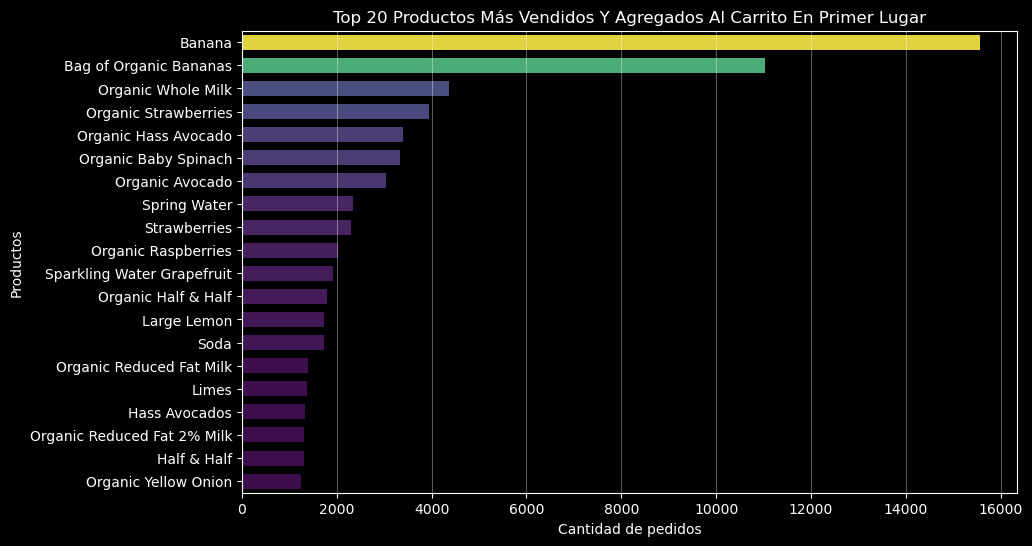

In [42]:
# Primero seleccionamos únicamente los productos que fueron agregados al carrito en primer lugar
top_20_prods = df_order_prod.merge(df_products, 'left', 'product_id').query('add_to_cart_order == 1')

# Luego agrupamos por 'product_name' y contamos la cantidad de 'order_id' para cada producto.
top_20_prods = pd.DataFrame(top_20_prods.groupby('product_name')['order_id'].count().sort_values(ascending=False)).rename(columns={'order_id':'orders'})
top_20_prods.head(20)

# Gráficamos la cantidad de pedidos por producto para los 20 productos más pedidos que fueron agregados al carrito en primer lugar.
plt.figure(figsize=(10,6))
sns.barplot(data=top_20_prods.head(20),
            y='product_name',
            x='orders',
            hue='orders',
            palette='viridis',
            legend=False,
            width=0.65
            )
plt.grid(axis='x', alpha=0.35)
plt.title('Top 20 productos más vendidos y agregados al carrito en primer lugar'.title())
plt.xlabel('Cantidad de pedidos')
plt.ylabel('Productos')
plt.show()

El orden en que los productos se agregan al carrito revela la jerarquía de necesidades del usuario. Al analizar los 20 artículos que con mayor frecuencia ocupan la primera posición (add_to_cart_order = 1), observamos patrones de prioridad absoluta:

* 🥇 **El Dominio de los Básicos**: Las **Bananas** y **Bag of Organic Bananas** no solo lideran en volumen, sino que son el punto de partida de la mayoría de los pedidos. Esto confirma que son artículos de "destino": el usuario entra a la plataforma específicamente por ellos y luego construye el resto de su pedido.

* 🥛 **Lácteos y Bebidas como Prioridad**: A diferencia del Top 20 de ventas generales, aquí ganan relevancia productos como la **Organic Whole Milk**, **Spring Water** y **Soda**. Esto sugiere que las bebidas, por su peso o necesidad inmediata, suelen ser lo primero que el usuario asegura en su carrito.

* ✨ **Los "Imprescindibles" de la Mañana**: La aparición de **Organic Half & Half** y leches reducidas en grasa en posiciones altas del ranking refuerza la idea de que los insumos para el desayuno y el café son motores de compra de alta prioridad.

* 🥗 **Consistencia en Perecederos**: La presencia recurrente de fresas, espinacas y aguacates orgánicos en el primer lugar subraya que la frescura es la propuesta de valor que motiva la apertura de la aplicación.

💡 **Insight de UX/UI**: Dado que estos 20 productos representan la "intención de inicio", colocarlos en una sección de **"Compra Rápida"** o **"Tus Favoritos de Siempre"** en la pantalla de inicio de la App reduciría significativamente el tiempo de fricción, permitiendo al usuario completar la parte más importante de su lista en un solo clic.

---

# 4.🏁 Conclusion general del proyecto

A continuación, se detallan los hallazgos técnicos y operativos derivados de cada fase del proyecto:

1. ### 🛠️ Calidad y Preprocesamiento de Datos

    El análisis reveló desafíos típicos de datos en entornos productivos que fueron mitigados exitosamente:

    * Duplicados Críticos: Se identificaron 15 registros duplicados en la tabla orders, localizados sistemáticamente los miércoles a las 2:00 AM.

    * Inconsistencias de Nomenclatura: Se detectaron 1,258 productos con nombres ausentes asociados al departamento "missing", los cuales fueron etiquetados como Unknown Product para mantener la integridad estadística.

    * Lógica de Negocio: Se validó que 28,817 registros sin days_since_prior_order no eran errores, sino que representaban el primer pedido de nuevos clientes (punto de partida del ciclo de vida).

2. ### 📈 Patrones de Comportamiento Temporal

    * Ventanas de Operación: La actividad se concentra entre las 09:00 y 16:00 horas.

    * Estacionalidad Semanal: El domingo y lunes lideran la demanda con más de 80,000 pedidos cada uno, reflejando el hábito de "reabastecimiento semanal".

    * Periodicidad de Recompra: Se identificó un patrón bimodal con picos de retorno a los 7 días (semanal) y 30 días (mensual), permitiendo segmentar estrategias de marketing según el ciclo del usuario.

3. ### 👥 Segmentación de Clientes

    * Concentración de Valor: El 1.48% de los usuarios genera el 10% del volumen total, representando el segmento VIP de la plataforma.

    * Frecuencia: El promedio es de 3.04 pedidos por cliente, aunque la variabilidad es alta (1 a 28 pedidos), lo que sugiere una base en crecimiento con una minoría de usuarios expertos.

    * Fidelidad Dinámica: Los usuarios más activos muestran una tasa de recompra del 77.3%, frente al 42.2% de los usuarios ocasionales.

4. ### 🔬 Insights de Productos

    * Tendencia Saludable: El 70% del Top 20 de productos más vendidos son orgánicos.

    * Anclas de Inventario: Bananas, frutas frescas y lácteos dominan tanto en volumen total como en tasa de reincidencia.

    * Efecto Pareto Extremo: Solo 18 productos (0.04% del catálogo) generan el 10% de las ventas totales, subrayando la importancia crítica de evitar roturas de stock en estos SKUs.

5. ### 🛒 Comportamiento de Carrito y Límites Técnicos

    * Densidad de Compra: El tamaño promedio es de 10.1 productos por pedido.

    * Prioridad de Selección: Los productos básicos (especialmente bananas) son los primeros en ser añadidos, funcionando como el imán que inicia la transacción.

    * Hallazgo de Ingeniería: Se identificó que pedidos con más de 64 artículos presentan limitaciones en el registro secuencial, un umbral técnico que debe considerarse para futuros modelos de predicción de carritos grandes.

    ---